In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.10.0'

#### Data (preparing and loading)
* Excel speadsheet
* Images of any kind
* Vedios
* Audio
* DNA
* Text

Machine learning is a game of two parts 
- Get Data into numerical representation.
- Build a model to learn patterns in that numerical representation.

To show case this, let's create some data using **linear regression**

Will use a linear regression formula to make a straight line with **known** parameters.

**Parameter** is some thing that machine learn.



### Linear Regresssion
**Defination**
- Linear Regression is a supervised learning algorithm used to model the relationship between:

    * Independent variables (features)

    * Dependent variable (target)
 

Simple linear regression 

    y = mx+b



In [2]:
# Create a known parameter

weight = 0.7 
bias   = 0.3

# create a range of numbers
start = 0
end = 1 
step = 0.02
X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10] 

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [3]:
len(X)

50

In [4]:
len(y)

50

#### What is Weight and Bias

**weight**

    * weight determine the strength and direction of influence of each input feature on the output.
    * Each feature has an associated weight 
    * A higher absolute weight means the feature has a greater impact on the prediction.

**Bias**

    * Bias is a constant added to the weighted sum.
    * It allows the model to shift the prediction up or down. independent of input values.
    * without the bias the model is passed through the origin.

        y = mx (no bias)
        y = mx + b (with bias)

#### Split data into training and test sets (one of the most important concept in machine learning)

##### What is **Generalization** ?

The ability for a machine learning model to perform well on data it hasn't seen before.

In [5]:
# Cerate a train/test split
train_split = int(0.8 *  len(X))
X_train,y_train = X[:train_split], y[:train_split]
X_test,y_test = X[train_split:],y[train_split:]

len(X_train),len(y_train),len(X_test),len(y_test)

(40, 40, 10, 10)

In [6]:
# Visualization of training and testing data
def plot_train_test_data(train_data=X_train,
                        train_labels=y_train,
                        test_data=X_test,
                        test_labels=y_test,
                        prediction=None):
    
    plt.figure(figsize=(8,6))
    # plot training data in Red Color 
    plt.scatter(train_data,train_labels,c="r",s=4,label="Training data")

    # Plot test data in green
    plt.scatter(test_data,test_labels,c="g",s=4,label="Testing data")

    # Check if there is any prediction
    if prediction is not None:
        # plot the prediction
        plt.scatter(test_data,prediction,c="b",label="Preditecd Data")

    plt.legend(prop={"size":10});
    

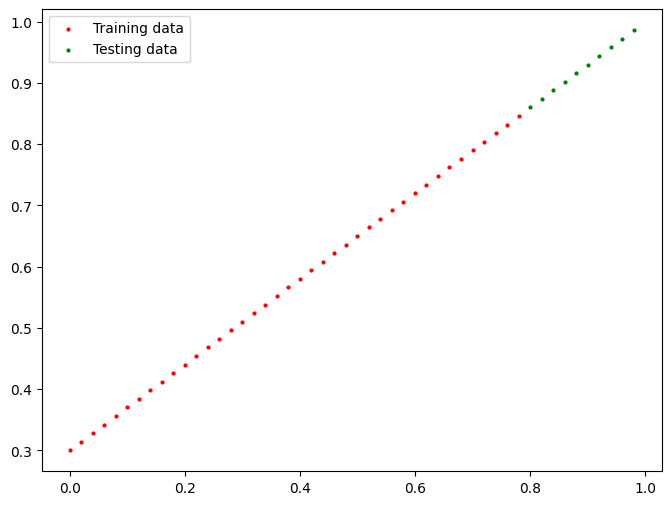

In [7]:
plot_train_test_data()

#### Build a model 

What the model does:
- Start with randorm values (weights and bias)
-  Look at training data and adjust the random values to better represent (or get closer to) the ideal values

How to do so?
- Gradient descent
- Backpropagation 

In [8]:
# Create a linear regression model

class LinearRegressionModel(nn.Module): # Almost everything in PyTorch inhertis from nn.Module 
    def __init__(self):
        super().__init__()
        # Define the weight and bias parameter (Initialization of the model parameters)
        self.weights = nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
        self.bias =  nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))

        '''
        requires_grad=True means PyTorch will track the gradients of the specific parameter for 
        use with torch.autograd and gradient descent(for many torch.nn) modules, requires_grad=True
        is set by default
        '''

        # Forward method to define the computation in the model 
        # any subclass of nn.Module is need to override forward() method
    def forward(self,x: torch.Tensor) -> torch.Tensor: # <- x is the input data
        return self.weights * x + self.bias # y = mx+b
    

    
        
        
    

#### PyTorch Model building essentials class 
- torch.nn -> Contains all of the building for computational graphs (a neural network can be considered as a computational graph)
- torch.nn.Parameter -> what parameters should out model try and learn, often a PyTorch layer from torch.nn will set these for us
- torch.nn.Module -> The base class for all neural network modules, if you subclass it, you should override the `forward()` method
- torch.optim -> This where the optimizers in PyTorch live, they help with gradient descent
- torch.utils.data.Dataset -> Represents a map between key(label) and sample(features) pairs of your data.Such as images and thier associated labels.
- torch.utils.data.DataLoader -> Creates a Python iterable over a torch Dataset(allows you to iterate over your data)
- `def forward()` -> All `nn.Module` subclasses require you to overwirte `forward()`, this method defines what happens in the forward computation

In [9]:
# Create a random Seed 
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)

# Craete an instance of the model 
model_0 = LinearRegressionModel()

# Checkout the parameters
list(model_0.parameters())


[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [10]:
# List named Parametes
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [11]:
weight,bias

(0.7, 0.3)

#### Making prediction using `torch.inference_mode()`

To check out model's predictive power. 

When we pass data through our model, it will run the data through `forward()` method

In [12]:
X_test,y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [13]:
# Make prediction with model
# inference_mode() <--- Disable all gradient descent 
with torch.inference_mode():
    y_preds = model_0(X_test)
y_preds

# Same thing with torch.no_grad() but inference_mode() is preferd
#with torch.no_grad():
#    y_preds = model_0(X_test)

#y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

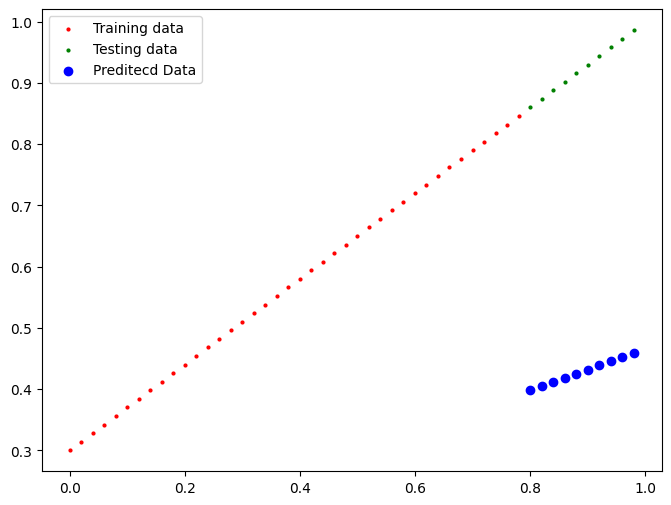

In [15]:
plot_train_test_data(prediction=y_preds)

#### Train Model
The whole idea of training is for a model to move from some unknown parameters(these may be random) to some known parameters.
Or in other words from a poor representation of the data to a better representation of data.

**Loss function** One way to measuer how wrong our model is
**Optimizer** Takes into account the loss of a model and adjust the model's parameters 
    - Inside the optimiser we often use to set two parameters:
         - `params` - The model parameters you'd like to optimize, for example `params=model_0.parameters()`
         - `lr` - **Learnin Rate** the learning rate is a hyperparameter that defines how big/small the optimizer with each step(a small lr results in small changes , a large lr result in large chages)

In [19]:
model_0.parameters()

<generator object Module.parameters at 0x112f81300>

In [23]:
# Parameter is a value that the model sets itself
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [24]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [28]:
# setup a loss function
loss_fn = nn.L1Loss()

# Setup an optimizer (stochastic gradient descent)
# Smaller the learning rate , smaller the change in the parameter
optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.01)

#### Which loss function and optimizer should I use?

##### This will be problem specific. But with experience, the idead of what works./

For Example, for a regression problem , a loss function of `nn.L1Loss()` and an optimizer like `torch.optim.SGD()` will work

But for problems for classifying whether a photo is dog or cat , then we can use `nn.BCELoss()`

### Building a training loop and testing loop in PyTorch

#### Steps to perform

- Loop through the data
- Forward pass (this involves data moving through our model's `forward()` function) to make predictions on data - also called `forward propagration`
- Calculate the loss (compare forward pass predictions to ground truth labels)
- Optimizer zero grad
- Loss backward - move backwards through the network to Calculate the gradient of each of the parameters of our model with respect to the loss (This is **BACKPROPAGATION**)
- Optimizer step - use the optmizer to adjust our model parameters to try and improve the loss (This is **GRADIENT DESCENT**)


In [31]:
with torch.no_grad():
    list(model_0.parameters())

In [64]:
# An epoch is One loop through the data
epochs = 50 

### Training
# Step - 1 : Loop Throght the Data
for epoch in range(epochs):
    # Set the model to training Mode 
    model_0.train() # train mode in PyTorch sets all parameters that require gradients to require gradients

    # Forward pass 
    y_pred = model_0(X_train)

    # Calculate the loss
    loss = loss_fn(y_pred,y_train)
    print(f"loss: {loss}")

    # Optimizer zero grad
    optimizer.zero_grad()

    # Perform backpropagation on the loss with respect to parameters of the model
    # Perform backpropagation on the loss function (computer the gradient of every parameter with requires_grad=True)
    loss.backward()

    # Step the optimizer (perform the gradient descent) to update the model's parameters with respect to the gradient calculated by loss.backward()
    optimizer.step()
    
    model_0.eval() # turns off gradaient tracking

print(model_0.state_dict())
    

loss: 0.017930403351783752
loss: 0.01758546754717827
loss: 0.017245203256607056
loss: 0.016896452754735947
loss: 0.01656000316143036
loss: 0.016210995614528656
loss: 0.01587124913930893
loss: 0.015525797381997108
loss: 0.01518223900347948
loss: 0.014840595424175262
loss: 0.01449323259294033
loss: 0.014155390672385693
loss: 0.01380639337003231
loss: 0.013468017801642418
loss: 0.013121192343533039
loss: 0.012779006734490395
loss: 0.012435990385711193
loss: 0.012089993804693222
loss: 0.01175079308450222
loss: 0.011401787400245667
loss: 0.01106478925794363
loss: 0.010716589167714119
loss: 0.010375778190791607
loss: 0.010031389072537422
loss: 0.00968676246702671
loss: 0.009346183389425278
loss: 0.00899775791913271
loss: 0.008660981431603432
loss: 0.008311985060572624
loss: 0.007972544990479946
loss: 0.007626780774444342
loss: 0.0072835348546504974
loss: 0.0069415755569934845
loss: 0.006594527512788773
loss: 0.006256377790123224
loss: 0.005907376762479544
loss: 0.005569317378103733
loss: 0.0

In [65]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6951])), ('bias', tensor([0.2993]))])

In [66]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6951])), ('bias', tensor([0.2993]))])

In [67]:
weight,bias

(0.7, 0.3)

In [68]:
with torch.inference_mode():
    y_pred_new = model_0(X_test)

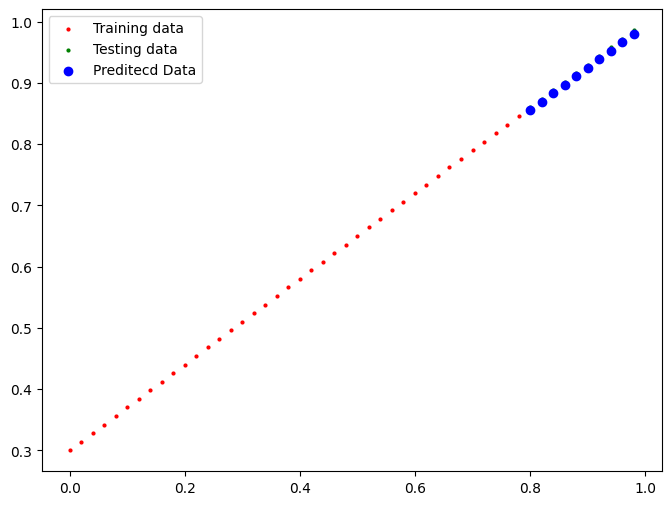

In [69]:
plot_train_test_data(prediction=y_pred_new)

### Saving a model in PyTorch

- There are 3 main methods for saving and loading a Model
      1. `torch.save()` - This allows you to save a model in python `pickle` format
      2.  `torch.load()` - This allows you to load a ssaved PyTorch object
      3.  `torch.nn.Module.load_state_dict()` - This allows to load a model's save state dictonary


In [70]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6951])), ('bias', tensor([0.2993]))])

#### What is `state_dict`?

- In PyTorch, the learnable parametes (i.e. weigts, and bias) of an `torch.nn.Module` model are contained in the model's parameters(associated with `model.parameters()`). A `state_dict` is simply a Python Object that maps each layer to its parameter tensor.

In [75]:
# Saving Our PyTorch model

from pathlib import Path

#1. Create a moedls directory
MODEL_PATH= Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

#2. Create model save path 
MODEL_NAME = "01_pytorch_random_data_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

#MODEL_SAVE_PATH

#3. Save the model state dict 
print(f"Saving Model into: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),f=MODEL_SAVE_PATH)


Saving Model into: models/01_pytorch_random_data_model.pth


In [76]:
!pwd

/Users/dipayandutta/Developer/python/machine-learning/pytorch


In [77]:
!ls -ltr models

total 8
-rw-r--r--@ 1 dipayandutta  staff  2125  2 Mar 20:25 01_pytorch_random_data_model.pth


#### Loading a PyTorch Model

Since we saved our model's `state_dict()` rather the entire model, will create a new instanace of the class

In [78]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6951])), ('bias', tensor([0.2993]))])

In [80]:
# To load in a saved state_dict we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()
#loaded_model_0.state_dict()
# Load the saved state_dict of model_0 (this will update the new instance with updated parameters)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))


<All keys matched successfully>

In [81]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6951])), ('bias', tensor([0.2993]))])

In [82]:
### Make some prediction with the newly loaded model

loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8554],
        [0.8693],
        [0.8832],
        [0.8971],
        [0.9110],
        [0.9249],
        [0.9388],
        [0.9527],
        [0.9666],
        [0.9805]])

In [86]:
model_0.eval()
with torch.inference_mode():
    y_preds = model_0(X_test)

y_preds

tensor([[0.8554],
        [0.8693],
        [0.8832],
        [0.8971],
        [0.9110],
        [0.9249],
        [0.9388],
        [0.9527],
        [0.9666],
        [0.9805]])

In [87]:
# Compare loaded_model_pred with original preds
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])